# Residency-3: Project-1 | Statistical R3_ExtLab | Jayant Ojha

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [132]:
#enabling each line of the cells to output, rather
#than just the line of each cell (for cells having multiple
#lines)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity="all"

In [165]:
import warnings 
warnings.filterwarnings('ignore')

In [134]:
import pandas as pd
import numpy as np

In [135]:
# from the URL: https://archive.ics.uci.edu/ml/datasets/Iris, the dataset features are named as below:
# 1. sepal length in cm  2. sepal width in cm  3. petal length in cm 4. petal width in cm  5. class: (either of
# Iris Setosa, Iris Versicolour or  Iris Virginica)
#Hence in absence of the header information on the datafile, we form a list of column names:
column_names = ["sepal_length_in_cm", "sepal_width_in_cm", "petal_length_in_cm", "petal_width_in_cm", "iris_class"]
#Now pd.read_csv can be used, to read this data format, at the same time, supplying the column-name list above, as
#"names" argument (in absence of headers, missing from the data file)
#The line below imports the data-set.
iris_data = pd.read_csv("./iris.data", names=column_names)

In [136]:
#Now we can print the 10 "random" rows(not just the "begining" or "last" 10 rows) from the data-set.
#though sample is "random" below but "random_state" option is used below to "fix" randomness across/over
#multiple runs of command
iris_data.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm,iris_class
14,5.8,4.0,1.2,0.2,Iris-setosa
98,5.1,2.5,3.0,1.1,Iris-versicolor
75,6.6,3.0,4.4,1.4,Iris-versicolor
16,5.4,3.9,1.3,0.4,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica
56,6.3,3.3,4.7,1.6,Iris-versicolor
141,6.9,3.1,5.1,2.3,Iris-virginica
44,5.1,3.8,1.9,0.4,Iris-setosa
29,4.7,3.2,1.6,0.2,Iris-setosa
120,6.9,3.2,5.7,2.3,Iris-virginica


In [137]:
#additionally to get the distribution of different
#classes for the dependent variable here
iris_data.iris_class.value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: iris_class, dtype: int64

## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [138]:
#additionally we look at the shape, info() and describe("all") for the above dataset
#to make conclusions on size, datatypes, and possible missing values (zero-values also?)
iris_data.shape

(150, 5)

In [139]:
#There are any "null" values for the feature columns
#as shown by the info() routine below
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal_length_in_cm    150 non-null float64
sepal_width_in_cm     150 non-null float64
petal_length_in_cm    150 non-null float64
petal_width_in_cm     150 non-null float64
iris_class            150 non-null object
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [140]:
#though redundant here, but an alternative way to reach the 
#above conclusion can be as follows (i.e. no non-null values
#for each column)
iris_data.isnull().sum()

sepal_length_in_cm    0
sepal_width_in_cm     0
petal_length_in_cm    0
petal_width_in_cm     0
iris_class            0
dtype: int64

In [141]:
#additionally to get the distribution of different
#classes for the dependent variable here
iris_data.groupby(["iris_class"]).count()

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
iris_class,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


In [142]:
#We have already seen above that there are no NaN (not a number) values
#we should additionally find out if there are any ZEROS present under the 
#columns (at least the quantitative value columns...as sepal or petal length
#width should not be 0.0...we better replace them with the respective column's
#median value...I hope mean can be avoided to unnecessary populate zeros with
#possible higher values towards outliers, median would be better)
def df_replace_zeros(df):
    for col in list(df.columns):
        df[col] = df[col].mask((df[col] == 0), df[col].median(skipna=True)).round(2)
    return df

In [143]:
column_names

['sepal_length_in_cm',
 'sepal_width_in_cm',
 'petal_length_in_cm',
 'petal_width_in_cm',
 'iris_class']

In [144]:
column_names.remove("iris_class")
iris_data[column_names] = df_replace_zeros(iris_data[column_names])

In [145]:
iris_data.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm,iris_class
14,5.8,4.0,1.2,0.2,Iris-setosa
98,5.1,2.5,3.0,1.1,Iris-versicolor
75,6.6,3.0,4.4,1.4,Iris-versicolor
16,5.4,3.9,1.3,0.4,Iris-setosa
131,7.9,3.8,6.4,2.0,Iris-virginica
56,6.3,3.3,4.7,1.6,Iris-versicolor
141,6.9,3.1,5.1,2.3,Iris-virginica
44,5.1,3.8,1.9,0.4,Iris-setosa
29,4.7,3.2,1.6,0.2,Iris-setosa
120,6.9,3.2,5.7,2.3,Iris-virginica


In [146]:
#Lets not only analysze the distribution of the various attributes
#but also see the different categorocal variable with "unique", "top"
# and "freq" attributes below (indicating the categorical variable attrrib's)
iris_data.describe(include="all")

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm,iris_class
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## Question 3 - Dealing with categorical data

Change all the classes to numericals (0 to 2).

In [147]:
iris_data['iris_class'] = iris_data['iris_class'].replace({'Iris-setosa': 0, 'Iris-versicolor':1, 'Iris-virginica':2})

In [148]:
iris_data.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm,iris_class
14,5.8,4.0,1.2,0.2,0
98,5.1,2.5,3.0,1.1,1
75,6.6,3.0,4.4,1.4,1
16,5.4,3.9,1.3,0.4,0
131,7.9,3.8,6.4,2.0,2
56,6.3,3.3,4.7,1.6,1
141,6.9,3.1,5.1,2.3,2
44,5.1,3.8,1.9,0.4,0
29,4.7,3.2,1.6,0.2,0
120,6.9,3.2,5.7,2.3,2


In [149]:
#the iris_class            150 non-null int64 tells that the conversion
#of categorical label for this dataset has taken place
iris_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
sepal_length_in_cm    150 non-null float64
sepal_width_in_cm     150 non-null float64
petal_length_in_cm    150 non-null float64
petal_width_in_cm     150 non-null float64
iris_class            150 non-null int64
dtypes: float64(4), int64(1)
memory usage: 5.9 KB


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [150]:
#Now first observe pairwise correlations.At this point
#we will need to import visulaisation modules
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

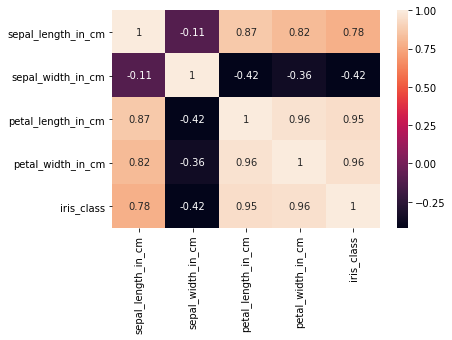

In [151]:
sns.heatmap(iris_data.corr(), annot=True)

*While observing the "association" of each independent variable with the target variable (using correlation values)
we find that all the independent variables are having values of correlation with dependent variable in the range \[-0.42, 0.78, 0.95, 0.96\] which is not in the range \[-0.1<x<0.1\]Hence we should NOT drop any of these independent variables while fitting the model.


## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [152]:
#The column variance, i.e. the variances for different independent variables
iris_data[column_names].var(axis=0)

sepal_length_in_cm    0.685694
sepal_width_in_cm     0.188004
petal_length_in_cm    3.113179
petal_width_in_cm     0.582414
dtype: float64

*While observing the variances for different independent variables, it appears that the "sepal_width_in_cm" column is the one which can potentially be dropped, but as it is still slightly higher than 0.1, strictly speaking not dropping it.
In another iteration, the effect can be seen after dropping the same though.

## Question 6

*Plot the scatter matrix for all the variables.*

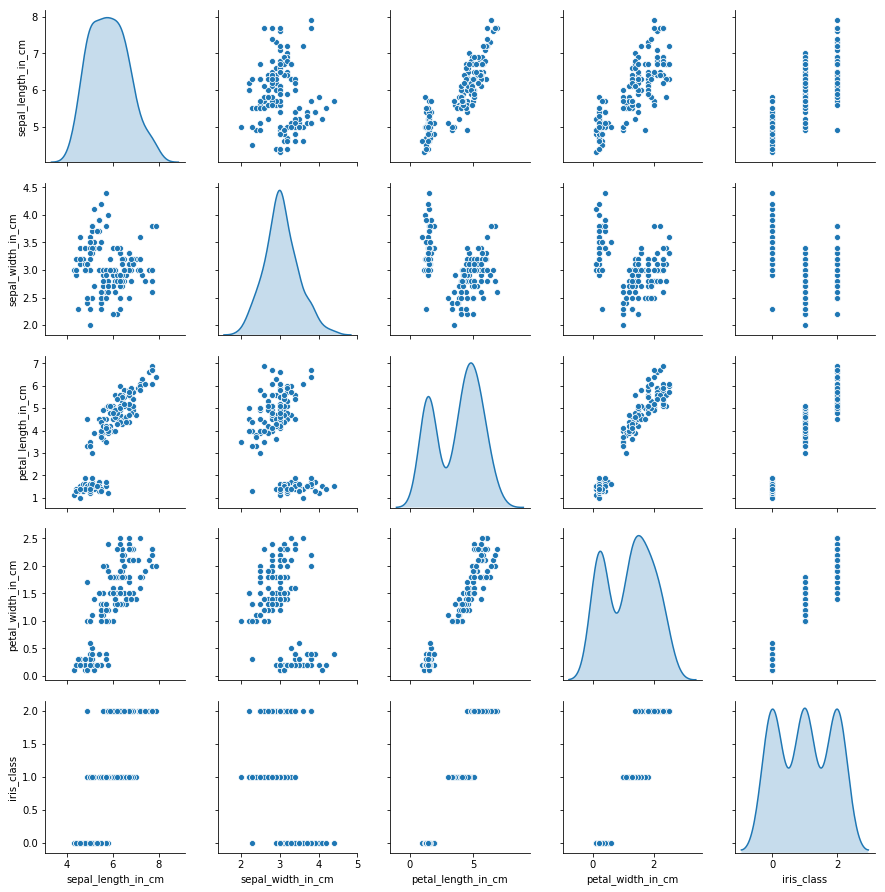

In [153]:
sns.pairplot( iris_data , diag_kind='kde')

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [154]:
#Before we can split the pre-processed dataset above into train & test data sets.
#As part of the step 6:i.e. "Transform the dataset for building machine learning model."
#we will require the related sklearn modules & routines.
#So that we can further process the x&y for suitability to
#KNN algorithm (esp. the scaling to zscores etc.)
from sklearn.model_selection import train_test_split

In [155]:
# Create a separate dataframe consisting only of the features i.e independent attributes
x = iris_data.drop(labels= "iris_class" , axis = 1)

In [156]:
x.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
14,5.8,4.0,1.2,0.2
98,5.1,2.5,3.0,1.1
75,6.6,3.0,4.4,1.4
16,5.4,3.9,1.3,0.4
131,7.9,3.8,6.4,2.0
56,6.3,3.3,4.7,1.6
141,6.9,3.1,5.1,2.3
44,5.1,3.8,1.9,0.4
29,4.7,3.2,1.6,0.2
120,6.9,3.2,5.7,2.3


In [157]:
#We have to convert the features into z scores, even though we know the scale/unit used here is cm.
# It is always adviced to scale numeric attributes in models that calculate distances.
#For it we will require the follwoing import
from scipy.stats import zscore

In [158]:
# convert the features into z scores, even though we know the scale/unit used here is cm.
# It is always adviced to scale numeric attributes in models that calculate distances.
x = x.apply(zscore)  # convert all attributes to Z scale 

In [159]:
x.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
14,-0.052506,2.189072,-1.455004,-1.312977
98,-0.900681,-1.281972,-0.431421,-0.129720
75,0.916837,-0.124958,0.364699,0.264699
16,-0.537178,1.957669,-1.398138,-1.050031
131,2.492019,1.726266,1.502013,1.053537
56,0.553333,0.569251,0.535296,0.527645
141,1.280340,0.106445,0.762759,1.447956
44,-0.900681,1.726266,-1.056944,-1.050031
29,-1.385353,0.337848,-1.227541,-1.312977
120,1.280340,0.337848,1.103953,1.447956


In [160]:
# Capture the class values from the 'iris_class' column into a pandas series akin to array 
y = iris_data[["iris_class"]]

In [161]:
y.sample(n=10, random_state=1)

,iris_class
14,0
98,1
75,1
16,0
131,2
56,1
141,2
44,0
29,0
120,2


In [162]:
#Now we can split the data set under train and test sets.
test_size = 0.3 #For splitting the train: test observation of 80:20
rand_seed = 67 #for reproducibilty of test across several iterations
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=rand_seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [163]:
#Now we are ready to fit the model and hence the related
#module is imported
from sklearn.neighbors import KNeighborsClassifier

In [164]:
#NNH = KNeighborsClassifier(n_neighbors= 21)
NNH = KNeighborsClassifier(n_neighbors= 3)

In [166]:
# Call Nearest Neighbour algorithm
NNH.fit(x_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=None, n_neighbors=3, p=2,
           weights='uniform')

In [167]:
#To asses the model here are a few required imports.
from sklearn.metrics import accuracy_score, recall_score, precision_score

In [168]:
# For every test data point, predict it's label based on 5 nearest neighbours in this model. The majority class will 
# be assigned to the test data point
predicted_labels = NNH.predict(x_test)

In [169]:
accuracy_score(y_test, predicted_labels)

0.9333333333333333

In [170]:
#Above set of steps shown for the K=3 alone
#can now be condensed in a single function
#which can be used to accept a "list" of
#k-values to calculate accuracy for individual
#k-values (3,5, & 9 for this question)
def KnnModelAccuracy(k_value_list):
    df = pd.DataFrame(index=["ModelAccuracyScore", "MisclassificationError"])
    for idx in k_value_list:
        NNH = KNeighborsClassifier(n_neighbors= idx)
        NNH.fit(x_train, y_train)
        predicted_labels = NNH.predict(x_test)
        accuracy = accuracy_score(y_test, predicted_labels)
        mis_class_err = 1- accuracy
        df["K={}".format(idx)] = [accuracy, mis_class_err]
    return df      

In [171]:
#Print the Accuracy of the model with different values of k=3,5,9
k_list = [3,5,9]
KnnModelAccuracy(k_list)

,K=3,K=5,K=9
ModelAccuracyScore,0.933333,0.933333,0.955556
MisclassificationError,0.066667,0.066667,0.044444


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [172]:
#for k= 1,3,5...19
k_plot_list = [x for x in range(1,21) if x%2!=0]
results= KnnModelAccuracy(k_plot_list)
results
print("The k value for the model with minimum:{}".format(results.T[['MisclassificationError']].idxmin()))

,K=1,K=3,K=5,K=7,K=9,K=11,K=13,K=15,K=17,K=19
ModelAccuracyScore,0.933333,0.933333,0.933333,0.933333,0.955556,0.955556,0.955556,0.888889,0.888889,0.911111
MisclassificationError,0.066667,0.066667,0.066667,0.066667,0.044444,0.044444,0.044444,0.111111,0.111111,0.088889


The k value for the model with minimum:MisclassificationError    K=9
dtype: object


*Actually for K=9, 11 & 13 the value of Misclassification Error is lowest for this random sampling.*

## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

Text(0.5, 0, 'KNN Model K-values')

Text(0, 0.5, 'Misclassification Error')

Text(0.5, 1.0, 'Misclassification Error vs. K-value Plot')

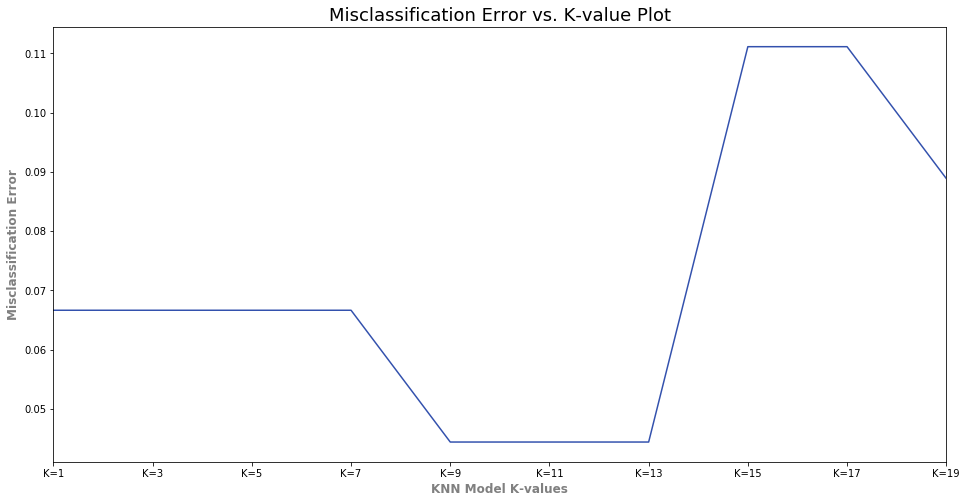

In [173]:
results.T['MisclassificationError'].plot(figsize=(16,8),color='#002699',alpha=0.8)
plt.xlabel("KNN Model K-values",fontsize=12,fontweight='bold',color='gray')
plt.ylabel('Misclassification Error',fontsize=12,fontweight='bold',color='gray')
plt.title("Misclassification Error vs. K-value Plot",fontsize=18)
plt.show()

# Naive Bayes with Iris Data

In [174]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'iris_class' is my dependent variables, name it y and independent set data as X

In [175]:
#Same as earlier, in the case of knn, here too repeat the following step again,
# Create a separate dataframe consisting only of the features i.e independent attributes
X = iris_data.drop(labels= "iris_class" , axis = 1)

In [176]:
#Same as earlier, in the case of knn, here too here too repeat the following step again,
# Capture the class values from the 'iris_class' column into a pandas series akin to array 
Y = iris_data[["iris_class"]]

In [177]:
#Check the dataset
print(Y)
print(X)

     iris_class
0             0
1             0
2             0
3             0
4             0
5             0
6             0
7             0
8             0
9             0
10            0
11            0
12            0
13            0
14            0
15            0
16            0
17            0
18            0
19            0
20            0
21            0
22            0
23            0
24            0
25            0
26            0
27            0
28            0
29            0
..          ...
120           2
121           2
122           2
123           2
124           2
125           2
126           2
127           2
128           2
129           2
130           2
131           2
132           2
133           2
134           2
135           2
136           2
137           2
138           2
139           2
140           2
141           2
142           2
143           2
144           2
145           2
146           2
147           2
148           2
149           2

[150 ro

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

In [178]:
#Same as earlier, in the case of knn, here too here too repeat the following step again,
#to get the distribution of different classes for the dependent/target variable here:
iris_data.groupby(["iris_class"]).count()

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
iris_class,,,,
0,50,50,50,50
1,50,50,50,50
2,50,50,50,50


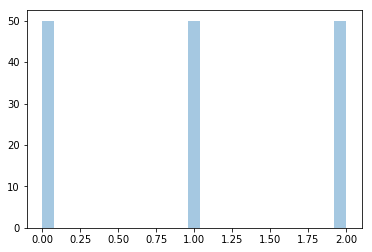

In [179]:
#Plot distribution of target variable using seaborn displot func (though a bar diagram instead of histogram would've
#been a better choice?...this being a categorical variable?)
sns.distplot(y, bins=25, kde=False);

### Question 12 
Find Correlation among all variables and give your insights 

In [180]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

*Do we have to remove correlated features for the case of NB(and/or KNN)...i.e. the possible use of techniques like VIF?
As I think, based on the class-content, the NB and KNN don't work on the assumption of No-Collienarity (i.e. no such assumption to have any negative effect of correlated features....looked like, this was a concern for either the Logistic(and/or Linear) regression techniques??)*

### Split data in Training and test set in 80:20.

In [181]:
#Now we can split the data set under train and test sets.
test_size = 0.2 #For splitting the train: test observation of 70:30
rand_seed = 67 #for reproducibilty of test across several iterations
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=rand_seed)

In [182]:
X_train.shape
X_test.shape

(120, 4)

(30, 4)

In [183]:
X_train.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
117,7.7,3.8,6.7,2.2
118,7.7,2.6,6.9,2.3
120,6.9,3.2,5.7,2.3
7,5.0,3.4,1.5,0.2
76,6.8,2.8,4.8,1.4
57,4.9,2.4,3.3,1.0
81,5.5,2.4,3.7,1.0
106,4.9,2.5,4.5,1.7
88,5.6,3.0,4.1,1.3
34,4.9,3.1,1.5,0.1


In [184]:
X_test.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
61,5.9,3.0,4.2,1.5
72,6.3,2.5,4.9,1.5
74,6.4,2.9,4.3,1.3
68,6.2,2.2,4.5,1.5
83,6.0,2.7,5.1,1.6
3,4.6,3.1,1.5,0.2
50,7.0,3.2,4.7,1.4
32,5.2,4.1,1.5,0.1
9,4.9,3.1,1.5,0.1
79,5.7,2.6,3.5,1.0


### Question 13 
Do Feature Scaling 

In [185]:
# Use StandardScaler or similar methods

*Not sure if I am aware of these methods as yet & also real relevance in this case: i.e. of applying this StandardScalar (i.e. z-score?) as it is assumed that the GaussinaNB **doesn't strictly** have the z-score requirement as is the case of KNN distance calculation*
*But below is the solution*

Text(0.5, 1.0, 'Before Scaling')

Text(0.5, 1.0, 'After Standard Scaler')

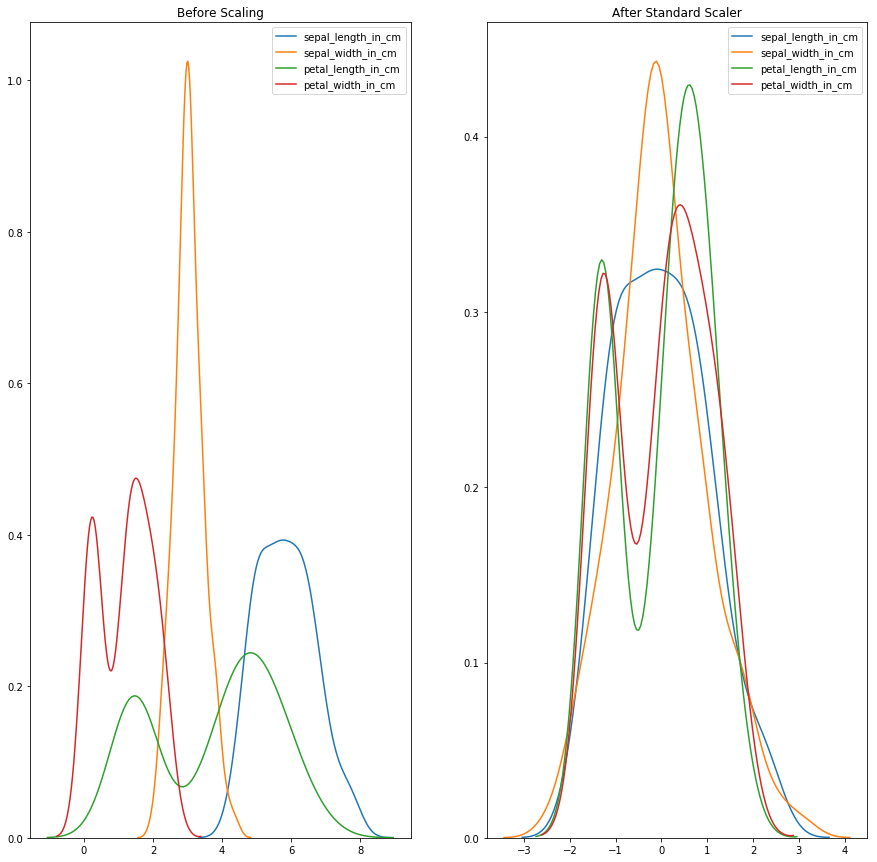

In [189]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(X)
scaled_X = pd.DataFrame(scaled_X, columns=column_names)
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in column_names:
    sns.kdeplot(X[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in column_names:
    sns.kdeplot(scaled_X[i], ax=ax2)
plt.show()

In [190]:
#Now we should split the data set again post the above preprocessing (i.e. with scaled_X & Y combination) under train and test sets.
test_size = 0.2 #For splitting the train: test observation of 70:30
rand_seed = 67 #for reproducibilty of test across several iterations
X_train, X_test, Y_train, Y_test = train_test_split(scaled_X, Y, test_size=test_size, random_state=rand_seed)

In [191]:
X_train.shape
X_test.shape

(120, 4)

(30, 4)

In [192]:
X_train.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
117,2.249683,1.726266,1.672610,1.316483
118,2.249683,-1.050569,1.786341,1.447956
120,1.280340,0.337848,1.103953,1.447956
7,-1.021849,0.800654,-1.284407,-1.312977
76,1.159173,-0.587764,0.592162,0.264699
57,-1.143017,-1.513375,-0.260824,-0.261193
81,-0.416010,-1.513375,-0.033361,-0.261193
106,-1.143017,-1.281972,0.421564,0.659118
88,-0.294842,-0.124958,0.194102,0.133226
34,-1.143017,0.106445,-1.284407,-1.444450


In [193]:
X_test.sample(n=10, random_state=1)

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm
61,0.068662,-0.124958,0.250967,0.396172
72,0.553333,-1.281972,0.649027,0.396172
74,0.674501,-0.356361,0.307833,0.133226
68,0.432165,-1.976181,0.421564,0.396172
83,0.189830,-0.819166,0.762759,0.527645
3,-1.506521,0.106445,-1.284407,-1.312977
50,1.401508,0.337848,0.535296,0.264699
32,-0.779513,2.420475,-1.284407,-1.444450
9,-1.143017,0.106445,-1.284407,-1.444450
79,-0.173674,-1.050569,-0.147093,-0.261193


### Question 14 
Train and Fit NaiveBayes Model

In [194]:
#Selection & instantiaton of the model
#based on the fact that the feature variables
#are continuous variable with Gaussian distribution
model = GaussianNB()

In [195]:
#Fit the model
model.fit(X_train, Y_train)
print(model)

GaussianNB(priors=None, var_smoothing=1e-09)

GaussianNB(priors=None, var_smoothing=1e-09)


In [196]:
#Predict
testPreds = model.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [197]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve

In [199]:
# show Confusion Matrix
metrics.confusion_matrix(testPreds, Y_test)

array([[ 9,  0,  0],
       [ 0, 14,  0],
       [ 0,  1,  6]], dtype=int64)

In [200]:
# show accuracy
model_score = model.score(X_test, Y_test)
model_score

0.9666666666666667

In [201]:
#Show precision
#precision_score(y_test, y_pred, average=None) will return the precision scores for each class
testPrecision = precision_score(Y_test, testPreds, average=None)
testPrecision

array([1.        , 1.        , 0.85714286])

In [202]:
#Show precision
#precision_score(y_test, y_pred, average='micro') will return the total ratio of tp/(tp + fp)
testPrecision = precision_score(Y_test, testPreds, average='micro')
testPrecision

0.9666666666666667

In [203]:
#Show recall
#recall_score(y_test, y_pred, average=None) will return the precision scores for each class
testRecall = recall_score(Y_test, testPreds, average=None)
testRecall

array([1.        , 0.93333333, 1.        ])

In [204]:
#Show recall
#recall_score(y_test, y_pred, average='micro') will return the total ratio of tp/(tp + fn)
testRecall = recall_score(Y_test, testPreds, average='micro')
testRecall

0.9666666666666667

# End Of Assignment